# Libraries

In [75]:
import pandas as pd
import networkx as nx
import numpy as np
import osmnx as ox
import geopandas as gpd
import pickle
from tqdm import tqdm
import os
import rasterio as rs
import random
import matplotlib.pyplot as plt
from haversine import haversine, Unit

In [4]:
# Set home directory
home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Research/Global road network resilience/01_data' # CURA
home_dir = '/Users/yiyi/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology(2)/Research/Global road network resilience/01_data' # SCARP

# Validation

## Road segment height

In this project, we extract the 

### Step 1: Sample 5 networks for each World Bank region (7 regions, 35 networks worldwide)

In [ ]:
# Read settlement cluster shapefiles
clusters_2564_dir = "/final_bnd/poly_2564_WB_regions.shp"
clusters_2564 = gpd.read_file(home_dir + clusters_2564_dir)

# Number of random network IDs to select per World Bank region
n_samples = 5

# Group by 'REGION_WB' and sample 'n_samples' random rows from each group
# The result will be a new DataFrame containing the sampled rows.
random_network_ids_per_region = clusters_2564.groupby('REGION_WB').sample(n=n_samples, random_state=2025)

# Save sampled network ids in csv file
random_network_ids_per_region.to_csv(home_dir+"/road_elevation_validation/sampled_35networks.csv")

In [66]:
# Print only the net_id and region
print("\nSampled 'net_id' for each region:")
print(random_network_ids_per_region[['REGION_WB', 'net_id']])


Sampled 'net_id' for each region:
                       REGION_WB  net_id
599          East Asia & Pacific  1679.0
1338         East Asia & Pacific  2849.0
1545         East Asia & Pacific  3225.0
2160         East Asia & Pacific  4215.0
1444         East Asia & Pacific  3021.0
2598       Europe & Central Asia   847.0
121        Europe & Central Asia  1143.0
1668       Europe & Central Asia   343.0
1805       Europe & Central Asia   368.0
1346       Europe & Central Asia   287.0
1639   Latin America & Caribbean  3366.0
894    Latin America & Caribbean  2002.0
1615   Latin America & Caribbean  3328.0
1965   Latin America & Caribbean  3962.0
2070   Latin America & Caribbean  4103.0
929   Middle East & North Africa  2062.0
452   Middle East & North Africa  1521.0
833   Middle East & North Africa  1926.0
1161  Middle East & North Africa  2550.0
932   Middle East & North Africa  2066.0
686                North America  1753.0
394                North America  1456.0
174                Nor

### Step 2: Extract OSM road networks

In [ ]:
# CSV file with sampled network IDs
random_network_ids_per_region = pd.read_csv(home_dir+"/road_elevation_validation/sampled_35networks.csv", index_col=0)

# Define coordinate reference system: WGS84 - World Geodetic System 1984 used in GPS
crs_lonlat = {'init': 'epsg:' + str(4326)}

# Read in the shapefile with the convex hulls of the settlement cluster boundaries
convex_hull_2564_shp = gpd.read_file(home_dir + '/final_bnd/poly_2564_WB_regions.shp').to_crs(crs_lonlat)

# Loop through the sampled network ids and extract OSM road networks
for net_id in random_network_ids_per_region.net_id.values:
    # Select convexhull poly
    convex_hull_sel = convex_hull_2564_shp[convex_hull_2564_shp["net_id"] == net_id].iloc[0]
    G = ox.graph_from_polygon(convex_hull_sel.geometry, network_type='drive_service')
    with open(home_dir + '/road_elevation_validation/sampled_networks/g_raw_drive_conv_' + str(net_id) + '.pk', 'wb') as handle:
        pickle.dump(G, handle, protocol=2)

OPTIONAL: examine road types in raw OSM networks

In [197]:
# [OPTIONAL] This cell examines the highway classes or road types
# Initiate dataframe to store road types
net_type_df = pd.DataFrame(columns=['net_id', 'net_types'], index=range(35))
counter = 0
net_type_lst = [] # Initiate list of network types

# Examine the road types
# Function to remove list nestings in highway road classes
def removeNestings(l): 
    output = []
    for i in l: 
        if type(i) == list: 
            output.extend(removeNestings(i))  # Use extend to add flattened results
        else: 
            output.append(i)
    return output

for file in os.listdir(home_dir + '/road_elevation_validation/sampled_networks/'):
    if file.endswith('.pk'):
        G = pickle.load(open(home_dir + '/road_elevation_validation/sampled_networks/' + file, 'rb'))
        net_id = int(file.split("_")[-1].split(".")[0])
        net_type_df.at[counter, 'net_id'] = net_id
        # Highway class unique values
        highway_class_dict = nx.get_edge_attributes(G,'highway')
        highway_class_lst = []
        for item in highway_class_dict.values():
            highway_class_lst.append(item)
        net_type_df.at[counter, 'net_types'] = list(set(removeNestings(highway_class_lst)))
        counter += 1
        net_type_lst.append(list(set(removeNestings(highway_class_lst))))

Below a dataframe of network id and unique road network types is created.

In [201]:
net_type_df.head(5)

,net_id,net_types
0,1521,"[tertiary, living_street, tertiary_link, resid..."
1,2550,"[tertiary, tertiary_link, residential, trunk_l..."
2,287,"[tertiary, living_street, tertiary_link, resid..."
3,3910,"[tertiary, living_street, residential, trunk_l..."
4,3481,"[tertiary, living_street, tertiary_link, resid..."


These are the unique road network types for all 35 sampled networks

In [207]:
set(removeNestings(net_type_lst))

{'yes', 'trunk_link', 'secondary_link', 'escape', 'step', 'tertiary_link', 'trunk', 'bus_stop', 'residential', 'motorway_link', 'primary_link', 'road', 'tertiary', 'living_street', 'service', 'crossing', 'unclassified', 'motorway', 'secondary', 'primary', 'busway'}

Remove highway classes that cause data bias

In [229]:
# Identify highway classes to remove
highway_classes_to_remove = [
    'yes',
    'escape',
    'step',
    'tertiary_link',
    'bus_stop',
    'residential',
    'tertiary',
    'living_street',
    'service',
    'crossing',
    'unclassified',
    'busway'
                             ]
for file in os.listdir(home_dir + '/road_elevation_validation/sampled_networks/'):
    if file.endswith('.pk'):
        net_id = int(file.split('_')[-1].split('.')[0])
        G = pickle.load(open(home_dir + '/road_elevation_validation/sampled_networks/' + file, 'rb'))
        G_lite = G.copy()
        for i,j,data in G.edges.data():
            highway_cls = data['highway']
            if highway_cls in highway_classes_to_remove:
                G_lite.remove_edge(i, j)
        # Remove isolated nodes as a result of the edge removal
        G_lite.remove_nodes_from(list(nx.isolates(G_lite)))
        with open(home_dir + '/road_elevation_validation/sampled_networks_lite/graph_cov_lite_' + str(int(net_id)) + '.pk', 'wb') as handle:
                pickle.dump(G_lite, handle, protocol=2)


### Step 3: Attach elevation values to road network

In [ ]:
# Extract road elevation using Google API
for file in os.listdir(home_dir + '/road_elevation_validation/sampled_networks_lite/'):
    if file.endswith('.pk'):
        net_id = int(file.split('_')[-1].split('.')[0])
        G = pickle.load(open(home_dir + '/road_elevation_validation/sampled_networks_lite/' + file, 'rb'))
        # add elevation to each of the nodes, using the google elevation API, then calculate edge grades
        G = ox.elevation.add_node_elevations_google(G, api_key='your API key here')
        G = ox.add_edge_grades(G)
        # Save as graphml
        ox.io.save_graphml(G, home_dir + f'/road_elevation_validation/sampled_network_lite_elev_graphml/graph_cov_lite_elev_{net_id}.graphml')
        # Save as geopackage
        ox.io.save_graph_geopackage(G, home_dir + f"/road_elevation_validation/sampled_network_lite_elev_gpkg/graph_cov_lite_elev_{net_id}.gpkg")

## Road closures (Houston, USA)

In [3]:
houston_graph_10flood = pickle.load(open(home_dir + '/Harvey_validation/G_cov_no_r_2139_10flooded.pk', 'rb'))

/var/folders/nc/ywj4rgkn46l95_tqft45f5640000gs/T/ipykernel_19125/4091128666.py:1: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  houston_graph_10flood = pickle.load(open(home_dir + '/Harvey_validation/G_cov_no_r_2139_10flooded.pk', 'rb'))


In [ ]:
# Critical inundation thresholds
gamma_lst = [0.3, 0.25, 0.2, 0.15]

# Flood return period
rp = 1000

for gamma in gamma_lst:
    # Make a copy of the graph with flood inundation values
    houston_disrupted_graph = houston_graph_10flood.copy()
    # Delete nodes with flood inundation greater than 30mm or 0.3m
    for node_id, node_data in houston_graph_10flood.nodes.data():
        if node_data['FUP_' + str(rp)] >= gamma:
            houston_disrupted_graph.remove_node(node_id)
    # Delete edges with flood inundation greater than 30mm or 0.3m
    houston_disrupted_graph2 = houston_disrupted_graph.copy()
    for start_id, end_id, edge_data in houston_disrupted_graph.edges.data():
        try:
            if edge_data['FUP_' + str(rp)] >= gamma:
                houston_disrupted_graph2.remove_edge(start_id, end_id)
        except KeyError:
            continue

## Travel disruption (Nanjing, China)

### Build network model

In [8]:
# Define coordinate reference system: WGS84 - World Geodetic System 1984 used in GPS
crs_lonlat = {'init': 'epsg:' + str(4326)}

# Read in the shapefile with the convex hulls of the settlement cluster boundaries
nanjing_bnd_shp = gpd.read_file(home_dir + '/01_public/Nanjing_validation/Nanjing_city_bnd.shp').to_crs(crs_lonlat)

# Extract OSM road network for Nanjing City
poly = nanjing_bnd_shp.geometry.iloc[0]
G = ox.graph_from_polygon(poly, network_type='drive_service')
with open(home_dir + '/01_public/Nanjing_validation/nj_raw_drive.pk', 'wb') as handle:
    pickle.dump(G, handle, protocol=2)

/opt/miniconda3/envs/global0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [ ]:
# Function to remove list nestings in highway road classes
def removeNestings(l): 
    output = []
    for i in l: 
        if type(i) == list: 
            output.extend(removeNestings(i))  # Use extend to add flattened results
        else: 
            output.append(i)
    return output

# Highway class unique values
highway_class_dict = nx.get_edge_attributes(G,'highway')
highway_class_lst = []
for item in highway_class_dict.values():
    highway_class_lst.append(item)

# Identify highway classes to remove
highway_classes_to_remove = [
    'tertiary_link',
    'road',
    'residential',
    'tertiary',
    'living_street',
    'service',
    'unclassified'
                             ]

# Delete 'highway' classes that are not included in the scope of study
G_lite = G.copy()
for i,j,data in G.edges.data():
    highway_cls = data['highway']
    if highway_cls in highway_classes_to_remove:
        G_lite.remove_edge(i, j)
    # Remove isolated nodes as a result of the edge removal
    G_lite.remove_nodes_from(list(nx.isolates(G_lite)))
    # Save resulting graph as pickle file
    with open(home_dir + '/01_public/Nanjing_validation/nj_lite.pk', 'wb') as handle:
        pickle.dump(G_lite, handle, protocol=2)

# Save as geopackage
ox.io.save_graph_geopackage(G_lite, home_dir + '/01_public/Nanjing_validation/nj_lite.gpkg')

# add elevation to each of the nodes, using the google elevation API, then calculate edge grades
G_lite = ox.elevation.add_node_elevations_google(G_lite, api_key='your api key here')
G_lite = ox.add_edge_grades(G_lite)

# Save as graphml
ox.io.save_graphml(G_lite, home_dir + '/01_public/Nanjing_validation/nj_lite_elev.graphml')
# Save as geopackage
ox.io.save_graph_geopackage(G_lite, home_dir + "/01_public/Nanjing_validation/nj_lite_elev.gpkg")

### Dry condition routing

In [132]:
# Load network/graph with edge speed and travel time
nj_graph = pickle.load(open(home_dir + '/Nanjing_validation/G_nj_flooded_speed_time.pk', 'rb'))

In [171]:
# dry simulation
# Load node probability
node_pop_prob = pd.read_csv(home_dir + '/Nanjing_validation/nj_pop_probability.csv', index_col=0)
# Only keep nodes that is matches the ones in the graph
nj_graph_node_lst = list(map(int, list(nj_graph.nodes())))
node_pop_prob_filtered = node_pop_prob[node_pop_prob['osmid'].isin(nj_graph_node_lst)]

# List of node osmnid and corresponding sample probability
node_osmid_lst = list(map(int, node_pop_prob_filtered.osmid.values))
node_prob_lst = list(node_pop_prob_filtered.p_1.values)

OD_df = pd.DataFrame(columns=[  'index',
                                'O_node_id',
                                'D_node_id',
                                'OD_route',
                                'OD_route_time_s'])

epsilon = float('inf')
travel_time_lst = []
index = 0

while epsilon > 0.01:
    # Sample origin
    sample_O_pt = random.choices(node_osmid_lst, node_prob_lst)[0]
    sample_D_pt = random.choices(node_osmid_lst, node_prob_lst)[0]
    while sample_O_pt == sample_D_pt:
            sample_D_pt = random.choices(node_osmid_lst, node_prob_lst)[0]

    #
    try:
        OD_route = nx.shortest_path(nj_graph, str(sample_O_pt), str(sample_D_pt), weight='travel_time') # route
        OD_route_time = nx.shortest_path_length(nj_graph, str(sample_O_pt), str(sample_D_pt), weight='travel_time') # seconds
        travel_time_lst.append(OD_route_time)
    
        OD_df.loc[index] = [index+1, sample_O_pt, sample_D_pt, OD_route, OD_route_time]

        if len(travel_time_lst) == 1:
                epsilon = float('inf')
        else:
                epsilon = abs(np.mean(travel_time_lst) - np.mean(travel_time_lst[:-1]))

        index += 1
    except nx.NetworkXNoPath:
        continue

OD_df.to_csv(home_dir + '/Nanjing_validation/nj_OD_df.csv')

### Wet condition routing

##### Step 1: Generate disrupted graphs under 10 return periods and 4 inundation thresholds (gamma = 0.3, 0.25, 0.2, 0.15, unit:meters)

In [120]:
# Load network/graph with edge speed and travel time
nj_graph = pickle.load(open(home_dir + '/Nanjing_validation/G_nj_flooded_speed_time.pk', 'rb'))
flooded_graphs_dir = home_dir + '/Nanjing_validation/flooded_graphs' # folder to store disrupted graphs

gamma_lst = [0.3, 0.25, 0.2, 0.15]

RP_lst = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]


for rp in RP_lst:
    print('I am working on RP=' + str(rp))
    for gamma in gamma_lst:
        
        nj_graph_copy = nj_graph.copy()
        # Delete nodes with flood inundation greater than 30cm or 0.3m
        for node_id, node_data in nj_graph.nodes.data():
            if node_data['FUP_max_rp' + str(rp)] >= gamma and node_data['FUP_max_rp' + str(rp)] < 99:
                nj_graph_copy.remove_node(node_id)

        # Add flood travel speed
        for start_id, end_id, edge_data in nj_graph_copy.edges.data():
            edge_water_depth_m = max(nj_graph_copy.nodes[start_id]['FUP_max_rp'+str(rp)], nj_graph_copy.nodes[end_id]['FUP_max_rp'+str(rp)])
            edge_flood_depth_mm = edge_data['FUP_max_rp'+str(rp)]*1000 # unit:mm
            designed_speed_ms = edge_data['ms'] # m/s
            theoretical_speed_ms = (86.9448 - (0.5529*edge_flood_depth_mm) + (0.0009*edge_flood_depth_mm*edge_flood_depth_mm))/3.6 # m/s
            speed_final = min(theoretical_speed_ms, designed_speed_ms)
            nj_graph_copy[start_id][end_id][0]['speed_ms_rp'+ str(rp) + "_" + str(gamma)] = speed_final
            nj_graph_copy[start_id][end_id][0]['time_s_rp'+ str(rp) + "_" + str(gamma)] = float(edge_data['length'])/speed_final

        with open(flooded_graphs_dir + '/nj_graph_disrupted_FUP_' + str(rp) + "_" + str(gamma)+ '.pk', 'wb') as handle:
            pickle.dump(nj_graph_copy, handle, protocol=2)

I am working on RP=5
I am working on RP=10
I am working on RP=20
I am working on RP=50
I am working on RP=75
I am working on RP=100
I am working on RP=200
I am working on RP=250
I am working on RP=500
I am working on RP=1000


##### Step 2: OD simulation in flooded graphs

In [ ]:
# Gamma = 0.3 meters
gamma = 0.3

# Load OD pairs from dry routing
OD_baseline = pd.read_csv(home_dir + '/Nanjing_validation/nj_OD_df.csv', index_col=0)

wet_OD_df = OD_baseline.copy()
# Load disrupted graph
RP_lst = [5, 10, 20, 50, 75, 100, 200, 250, 500, 1000]
for rp in RP_lst:
    # Initiate column to store new route
    wet_OD_df[f'OD_route_FUP_{rp}_{gamma}'] = None
    wet_OD_df[f'OD_time_s_FUP_{rp}_{gamma}'] = 0

    # Load disrupted graph
    nj_graph = pickle.load(open(home_dir + '/Nanjing_validation/flooded_graphs' + '/nj_graph_disrupted_FUP_' + str(rp) + "_" + str(gamma)+ '.pk', 'rb'))

    # Run travel simulation between OD pairs
    for row_idx in range(wet_OD_df.shape[0]):
        O_node_id = wet_OD_df.iloc[row_idx]['O_node_id']
        D_node_id = wet_OD_df.iloc[row_idx]['D_node_id']

        try:
            wet_OD_route = nx.shortest_path(nj_graph, str(O_node_id), str(D_node_id), weight=f'time_s_rp{rp}_{gamma}') # route
            wet_OD_route_time = nx.shortest_path_length(nj_graph, str(O_node_id), str(D_node_id), weight=f'time_s_rp{rp}_{gamma}') # seconds

            wet_OD_df.at[row_idx, f'OD_route_FUP_{rp}_{gamma}'] = wet_OD_route
            wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
        except:
            continue
wet_OD_df.to_csv(home_dir + f'/Nanjing_validation/nj_OD_df_flood10_{gamma}.csv')

/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/106330981.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1977.853143606548' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/106330981.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4479.487982746327' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wet_OD_df.at[row_idx, f'OD_time_s_FUP_{rp}_{gamma}'] = wet_OD_route_time
/var/folders/cy/f8598vm53cggn74m01d5s0rc0000gr/T/ipykernel_1485/106330981.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6486.482

### AMAP processing

In [23]:
# 20240711 flooding
ds,o_adcode,d_adcode,source_grid,target_grid,str_time,end_time,vehicle_type,vehicle_size,energy_type,o_xy,d_xy,cnt = [], [], [], [], [], [], [], [], [], [], [], [], []
path = home_dir + '/Nanjing_validation/Nanjing_WPW/Real Data/20240711.txt'
with open(path) as f:
    print(f.readline())
    k = 0
    while f.readable():
        if k % 1000000 == 0:
            print("Begin to deal with the ", k, "th row...")
        datas = f.readline().strip("\n").split(",")
        if len(datas) == 1:  # 若数据为空行，则代表已经到达尾行
            break
        ds.append(datas[0])    # 日期，格式为YYYYMMDD，如20230301
        o_adcode.append(datas[1])    # 起点城市代码(区县级)
        d_adcode.append(datas[2])    # 终点城市代码(区县级)
        source_grid.append(datas[3])    # 起点网格ID（100 米）
        target_grid.append(datas[4])    # 终点网格ID（100 米）
        str_time.append(datas[5])   # 开始时间，间隔为15 分钟，可能为空   1215 表示 12:15
        end_time.append(datas[6])   # 结束时间，间隔为15 分钟，可能为空
        vehicle_type.append(datas[7])   # 汽车类型，1 是货车，0 是汽车
        vehicle_size.append(datas[8])   # 汽车型号，重型货车、中型货车、小型货车等
        energy_type.append(datas[9])   # 是否为电车，1 为电车，0 为油车
        o_xy.append(datas[10])   # 起点网格中心点经纬度(GCJ-02 坐标系)
        d_xy.append(datas[11])   # 终点网格中心点经纬度(GCJ-02 坐标系)
        cnt.append(datas[12])   # 数量

        k += 1

# 20240718 baseline
path = home_dir + '/Nanjing_validation/Nanjing_WPW/Real Data/20240718.txt'
with open(path) as f:
    print(f.readline())
    k = 0
    while f.readable():
        if k % 1000000 == 0:
            print("Begin to deal with the ", k, "th row...")
        datas = f.readline().strip("\n").split(",")
        if len(datas) == 1:  # 若数据为空行，则代表已经到达尾行
            break
        ds.append(datas[0])    # 日期，格式为YYYYMMDD，如20230301
        o_adcode.append(datas[1])    # 起点城市代码(区县级)
        d_adcode.append(datas[2])    # 终点城市代码(区县级)
        source_grid.append(datas[3])    # 起点网格ID（100 米）
        target_grid.append(datas[4])    # 终点网格ID（100 米）
        str_time.append(datas[5])   # 开始时间，间隔为15 分钟，可能为空
        end_time.append(datas[6])   # 结束时间，间隔为15 分钟，可能为空
        vehicle_type.append(datas[7])   # 汽车类型，1 是货车，0 是汽车
        vehicle_size.append(datas[8])   # 汽车型号，重型货车、中型货车、小型货车等
        energy_type.append(datas[9])   # 是否为电车，1 为电车，0 为油车
        o_xy.append(datas[10])   # 起点网格中心点经纬度(GCJ-02 坐标系)
        d_xy.append(datas[11])   # 终点网格中心点经纬度(GCJ-02 坐标系)
        cnt.append(datas[12])   # 数量

        k += 1

ds,o_adcode,d_adcode,source_grid,target_grid,str_time,end_time,vehicle_type,vehicle_size,energy_type,o_xy,d_xy,cnt

Begin to deal with the  0 th row...
Begin to deal with the  1000000 th row...
ds,o_adcode,d_adcode,source_grid,target_grid,str_time,end_time,vehicle_type,vehicle_size,energy_type,o_xy,d_xy,cnt

Begin to deal with the  0 th row...
Begin to deal with the  1000000 th row...


In [28]:
od_df_amap = pd.DataFrame()
od_df_amap['ds'] = ds
od_df_amap['o_adcode'] = o_adcode
od_df_amap['d_adcode'] = d_adcode
od_df_amap['source_grid'] = source_grid
od_df_amap['target_grid'] = target_grid 
od_df_amap['str_time'] = str_time
od_df_amap['end_time'] = end_time
od_df_amap['vehicle_type'] = vehicle_type
od_df_amap['vehicle_size'] = vehicle_size
od_df_amap['energy_type'] = energy_type
od_df_amap['o_xy'] = o_xy
od_df_amap['d_xy'] = d_xy
od_df_amap['cnt'] = pd.to_numeric(cnt)

In [ ]:
""" duration calculation """
od_df_amap['str_time'] = od_df_amap['str_time'].apply(lambda x: int(x[:-2]) * 60 + int(x[-2:]))  # min
od_df_amap['end_time'] = od_df_amap['end_time'].apply(lambda x: int(x[:-2]) * 60 + int(x[-2:]))  # min

od_df_amap['dur_time'] = od_df_amap['end_time'] - od_df_amap['str_time'] # min

""" distance calculation """
od_df_amap['ox'] = pd.to_numeric(od_df_amap['o_xy'].apply(lambda row: row.split('_')[0]))   # CJ-02
od_df_amap['oy'] = pd.to_numeric(od_df_amap['o_xy'].apply(lambda row: row.split('_')[1]))
od_df_amap['dx'] = pd.to_numeric(od_df_amap['d_xy'].apply(lambda row: row.split('_')[0]))   # CJ-02
od_df_amap['dy'] = pd.to_numeric(od_df_amap['d_xy'].apply(lambda row: row.split('_')[1]))

od_df_amap['rad'] = od_df_amap.apply(lambda row: haversine((row['oy'], row['ox']), (row['dy'], row['dx']), unit=Unit.KILOMETERS), axis='columns')  # km

""" speed calculation """
dur_time_modified = od_df_amap['dur_time'].replace([0], 7.5)  # assume 0-15min 的trips 7.5 min
od_df_amap['speed'] = od_df_amap['rad'] * 1.4 / (dur_time_modified / 60)  # non linear ecoffcient 1.4  # km/h

In [86]:
od_df_amap_cleaned = od_df_amap[od_df_amap['speed'] <= 120]
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['dur_time'] >= 0) & (od_df_amap_cleaned['dur_time'] <= 60)]
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['rad'] > 0) & (od_df_amap_cleaned['rad'] < 50)]
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['o_adcode'].map(lambda x:x[:4]) == "3201") & (od_df_amap_cleaned['d_adcode'].map(lambda x:x[:4]) == "3201")]   # both origin and destination locates in nanjing
od_df_amap_cleaned = od_df_amap_cleaned[~((od_df_amap_cleaned['ox'] >= 137.8347) | (od_df_amap_cleaned['dx'] <= 72.004) | (od_df_amap_cleaned['oy'] <= 0.8293) | (od_df_amap_cleaned['dy'] >= 55.8271))]
od_df_amap_cleaned = od_df_amap_cleaned[(od_df_amap_cleaned['vehicle_type'] == '0')].reset_index(drop=True)

In [87]:
""" statistics """
# trips time
print("The fraction of trips within 15min: ", od_df_amap_cleaned[od_df_amap_cleaned['dur_time'] == 0]['cnt'].sum() / od_df_amap_cleaned['cnt'].sum())

# The fraction is 20%. We can assume the duration of these trips is 7.5 min
print("The fraction of trips within 45min: ", od_df_amap_cleaned[od_df_amap_cleaned['dur_time'] <= 45]['cnt'].sum() / od_df_amap_cleaned['cnt'].sum())
print("The fraction of trips above 60min: ", od_df_amap_cleaned[od_df_amap_cleaned['dur_time'] >= 60]['cnt'].sum() / od_df_amap_cleaned['cnt'].sum())

The fraction of trips within 15min:  0.21115562335152196
The fraction of trips within 45min:  0.9643788259616927
The fraction of trips above 60min:  0.03562117403830732


### Baseline Validation

In [88]:
### Ground truth from Amap
Amap_baseline_df = od_df_amap_cleaned[od_df_amap_cleaned['ds'] == '20240718']
Amap_baseline_df = Amap_baseline_df.sort_values(by="dur_time", ascending=True).reset_index(drop=True)
Amap_baseline_df["trip_num_cusum"] = np.cumsum(Amap_baseline_df["cnt"]) / max(np.cumsum(Amap_baseline_df["cnt"]))

### Simulation
OD_baseline = pd.read_csv(home_dir + '/Nanjing_validation/nj_OD_df.csv', index_col=0)
OD_baseline['OD_route_time_min'] = OD_baseline['OD_route_time_s']/60
OD_baseline_df = OD_baseline.sort_values(by="OD_route_time_min", ascending=True).reset_index(drop=True)
OD_baseline_df['cnt'] = 1
OD_baseline_df['trip_num_cusum'] = np.cumsum(OD_baseline_df["cnt"]) / max(np.cumsum(OD_baseline_df["cnt"]))

(-1.0, 61.0)

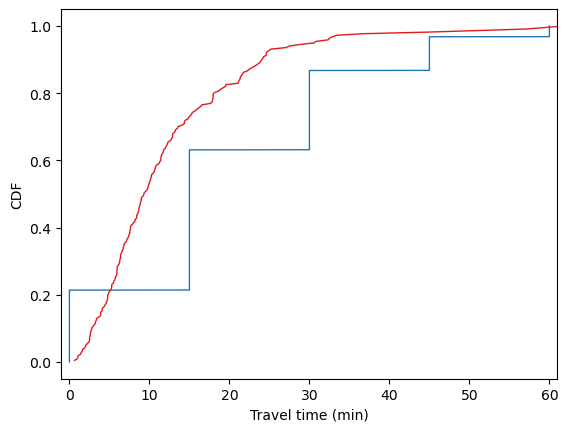

In [89]:
fig = plt.figure()
ax = fig.add_subplot(111)
# Amap data
ax.plot(Amap_baseline_df["dur_time"], Amap_baseline_df["trip_num_cusum"], label="Amap", color="#1f78b4", linewidth=1)
plt.ylabel("CDF")
plt.xlabel("Travel time (min)")

# simulation
ax.plot(OD_baseline_df["OD_route_time_min"], OD_baseline_df["trip_num_cusum"], label="Simulation", color="#e31a1c", linewidth=1)

plt.xlim(-1, 61)

#### KS test

In [90]:
from scipy.stats import ks_2samp
sample1 = []
for i in range(len(Amap_baseline_df)):
    sample1.extend( [Amap_baseline_df['dur_time'].iloc[i]] * round((Amap_baseline_df['cnt'].iloc[i])) )

sample2 = list(OD_baseline_df["OD_route_time_min"])
print(ks_2samp(sample1, sample2))

KstestResult(statistic=np.float64(0.5144069878817146), pvalue=np.float64(7.578039870495031e-54), statistic_location=np.float64(14.907612410115599), statistic_sign=np.int8(-1))
